# GA Image Approximation — Experiments

Run cells top to bottom. All src/ modules must be on the Python path (handled in cell 1).

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image

from fitness import build_fitness
from utils import load_target_pil, side_by_side, render
from ga import GeneticAlgorithm, GAConfig, EarlyStopping

from ga_operators.selection import TournamentSelection, RankSelection, RouletteSelection
from ga_operators.crossover import SinglePointCrossover, UniformCrossover, KPointCrossover
from ga_operators.mutation import GaussianMutation, ResetMutation, SwapMutation, CompositeMutation


TARGET_PATH = '../data/Girl_Pearl_Earing.png'
OUTPUT_DIR  = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('imports ok')

imports ok


## 1. Inspect target image

size: (300, 400), mode: RGB


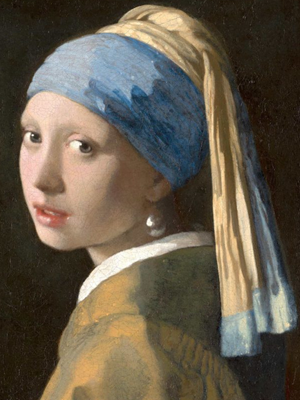

In [6]:
target_pil = load_target_pil(TARGET_PATH)
print(f'size: {target_pil.size}, mode: {target_pil.mode}')
display(target_pil)

## 2. Configure and run GA

In [7]:
fitness_fn = build_fitness('rmse', target_pil)

config = GAConfig(
    population_size    = 50,
    n_generations      = 500,
    crossover_rate     = 0.8,
    n_elites           = 1,
    n_workers          = 1,
    early_stopping     = EarlyStopping(patience=50, tolerance=1e-4),
    checkpoint_interval= 50,
    checkpoint_dir     = f'{OUTPUT_DIR}/checkpoints',
    seed               = 42,
)

mutation = CompositeMutation([
    GaussianMutation(mutation_rate=0.05, vertex_sigma=15.0, color_sigma=15.0),
    ResetMutation(mutation_rate=0.01),
    SwapMutation(mutation_rate=0.2, n_swaps=1),
])

ga = GeneticAlgorithm(
    fitness_fn = fitness_fn,
    selection  = TournamentSelection(tournament_size=5),
    crossover  = SinglePointCrossover(),
    mutation   = mutation,
    config     = config,
)

print(ga)

GeneticAlgorithm(
  selection=TournamentSelection(tournament_size=5),
  crossover=SinglePointCrossover(),
  mutation=CompositeMutation([GaussianMutation(rate=0.05, v_sigma=15.0, c_sigma=15.0), ResetMutation(rate=0.01), SwapMutation(rate=0.2, n_swaps=1)]),
  config=GAConfig(population_size=50, n_generations=500, crossover_rate=0.8, n_elites=1, n_workers=1, early_stopping=EarlyStopping(patience=50, tolerance=0.0001), checkpoint_interval=50, checkpoint_dir='../outputs/checkpoints', seed=42)
)


In [8]:
import logging
logging.basicConfig(level=logging.INFO, format='%(message)s')

best = ga.run()

print(f'\nbest fitness: {best.fitness:.4f}')

Initialising population (size=50).
Checkpoint saved -> ../outputs/checkpoints/best_gen_00000.json
gen    1 | best=66.1046 | mean=73.7980 | std=2.6784 | div=0.2091 | 0.9s
gen    2 | best=65.4992 | mean=70.0582 | std=3.0027 | div=0.2430 | 1.3s
gen    3 | best=63.6688 | mean=66.8275 | std=1.6116 | div=0.2035 | 1.7s
gen    4 | best=63.5483 | mean=65.6231 | std=0.9701 | div=0.2310 | 2.2s
gen    5 | best=62.7818 | mean=65.1649 | std=2.4418 | div=0.1374 | 2.6s
gen    6 | best=61.6314 | mean=63.9206 | std=0.9613 | div=0.1931 | 3.0s
gen    7 | best=61.0824 | mean=63.3367 | std=1.2382 | div=0.2040 | 3.5s
gen    8 | best=60.2760 | mean=62.4701 | std=1.1509 | div=0.2160 | 3.9s
gen    9 | best=59.6296 | mean=61.3729 | std=0.8687 | div=0.2073 | 4.3s
gen   10 | best=59.3401 | mean=60.8818 | std=0.8928 | div=0.2038 | 4.8s
gen   11 | best=58.7805 | mean=60.6031 | std=1.5821 | div=0.1598 | 5.2s
gen   12 | best=58.7805 | mean=60.0476 | std=0.7385 | div=0.2198 | 5.6s
gen   13 | best=57.7525 | mean=59.5916


best fitness: 35.2246


## 3. Save results

In [9]:
ga.save_log(f'{OUTPUT_DIR}/run_log.json')
ga.save_config(f'{OUTPUT_DIR}/run_config.json')

from utils import triangles_to_json, save_render
triangles_to_json(list(best.triangles), f'{OUTPUT_DIR}/best_individual.json')
save_render(render(best.triangles), f'{OUTPUT_DIR}/best_render.png')

print('results saved')

Generation log saved -> ../outputs/run_log.json
Run config saved -> ../outputs/run_config.json


results saved


## 4. Convergence plot

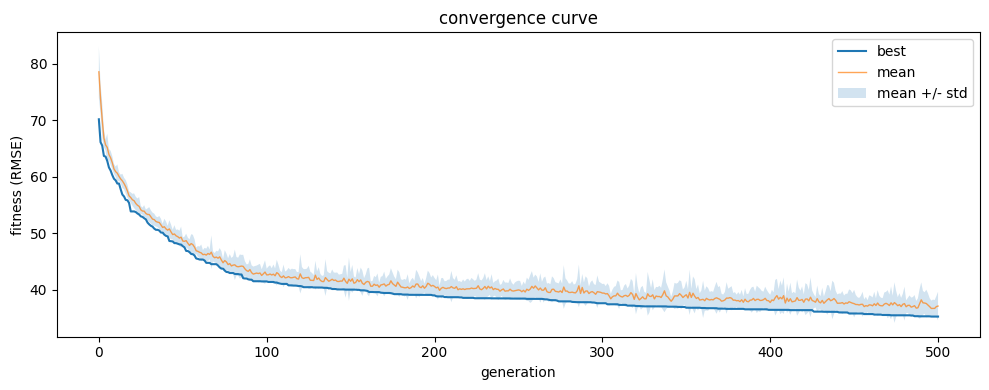

In [10]:
log_df = pd.DataFrame(ga.generation_log)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(log_df['generation'], log_df['best'],  label='best',  linewidth=1.5)
ax.plot(log_df['generation'], log_df['mean'],  label='mean',  linewidth=1.0, alpha=0.7)
ax.fill_between(
    log_df['generation'],
    log_df['mean'] - log_df['std'],
    log_df['mean'] + log_df['std'],
    alpha=0.2, label='mean +/- std'
)
ax.set_xlabel('generation')
ax.set_ylabel('fitness (RMSE)')
ax.set_title('convergence curve')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/convergence.png', dpi=150)
plt.show()

## 5. Visual comparison

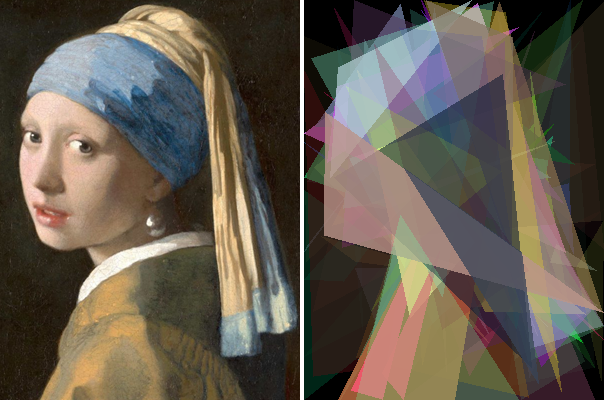

In [11]:
import numpy as np
target_arr  = np.array(target_pil)
best_arr    = render(best.triangles)

comparison = side_by_side(target_arr, best_arr)
display(comparison)
comparison.save(f'{OUTPUT_DIR}/comparison.png')